# Case Study: Ethereum Sentiment and Trading

This case notebook is organized as a compact end-to-end case study:
1. build the daily Ethereum sentiment series
2. align sentiment with the ETHE market proxy and create indicators
3. define and run the trading strategy
4. inspect the strategy outputs and supporting views
            


## 1. Build the Daily Ethereum Sentiment Series

This step aggregates weighted Reddit sentiment into a daily Ethereum series and saves the case-study dataset used downstream.
            


Saved daily sentiment to ETH_D.csv


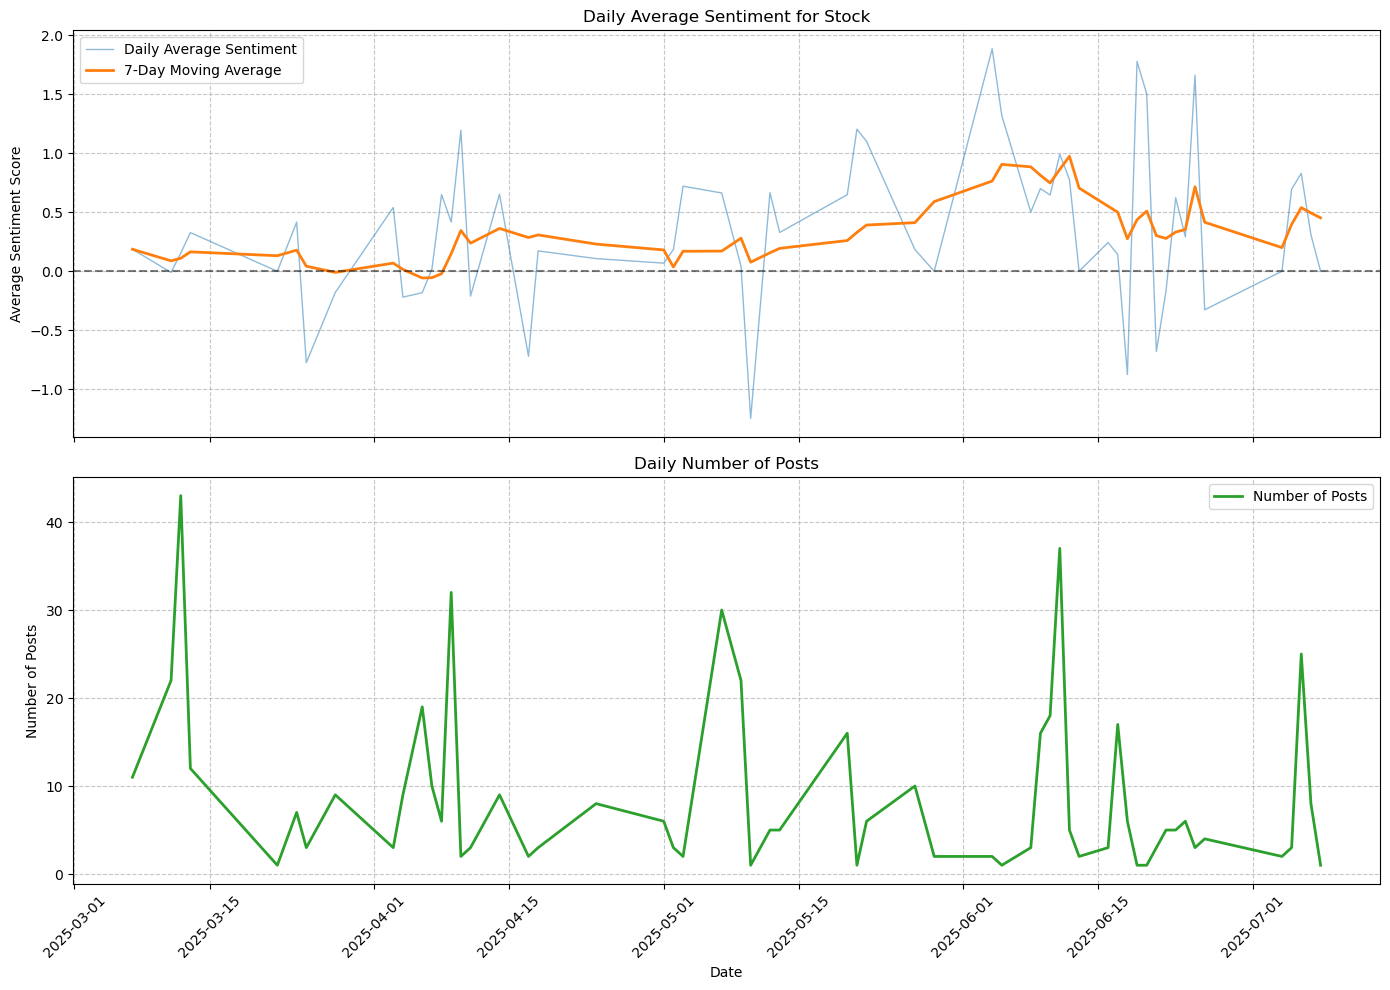


Sample of Daily Sentiment (first 10 rows):
        date  avg_sentiment  num_posts  sentiment_ma7
0 2025-03-07       0.186870         11       0.186870
1 2025-03-11      -0.009911         22       0.088480
2 2025-03-12       0.154384         43       0.110448
3 2025-03-13       0.328081         12       0.164856
4 2025-03-22       0.000000          1       0.131885
5 2025-03-24       0.416823          7       0.179375
6 2025-03-25      -0.775418          3       0.042976
7 2025-03-28      -0.179442          9      -0.009355
8 2025-04-03       0.540813          3       0.069320
9 2025-04-04      -0.219349          9       0.015930

Total valid posts: 500
Rows filtered out: 0
Date range: 2025-03-07 00:00:00 to 2025-07-08 00:00:00
Average posts per day: 8.8
Average sentiment: 0.3505


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# File paths
sentiment_file = 'ETH.csv'  # Your sentiment data file
output_csv = 'ETH_D.csv'
output_plot = 'daily_sentiment.png'

try:
    # Load dataset
    df_sentiment = pd.read_csv(sentiment_file)
    
    # Filter valid posts
    df_valid = df_sentiment[
        df_sentiment['created_utc'].notna() &
        df_sentiment['W_sentiment'].notna()
    ]
    
    # Convert created_utc to datetime and extract date
    df_valid['created_utc'] = pd.to_datetime(df_valid['created_utc'])
    df_valid['date'] = df_valid['created_utc'].dt.date
    
    # Group by date and calculate daily average sentiment
    daily_sentiment = df_valid.groupby('date').agg({
        'W_sentiment': 'mean',
        'created_utc': 'count'  # Count of posts per day
    }).reset_index()
    
    # Rename columns for clarity
    daily_sentiment.columns = ['date', 'avg_sentiment', 'num_posts']
    daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'])
    
    # Sort by date
    daily_sentiment = daily_sentiment.sort_values('date')
    
    # Calculate 7-day moving average
    daily_sentiment['sentiment_ma7'] = daily_sentiment['avg_sentiment'].rolling(window=7, min_periods=1).mean()
    
    # Save results
    daily_sentiment.to_csv(output_csv, index=False)
    print(f"Saved daily sentiment to {output_csv}")
    
    # --- Visualization ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Plot 1: Daily Sentiment
    ax1.plot(
        daily_sentiment['date'],
        daily_sentiment['avg_sentiment'],
        color='#1f77b4',
        alpha=0.5,
        label='Daily Average Sentiment',
        linewidth=1
    )
    ax1.plot(
        daily_sentiment['date'],
        daily_sentiment['sentiment_ma7'],
        color='#ff7f0e',
        label='7-Day Moving Average',
        linewidth=2
    )
    ax1.set_ylabel('Average Sentiment Score')
    ax1.set_title('Daily Average Sentiment for Stock')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax1.legend()
    
    # Plot 2: Number of Posts
    ax2.plot(
        daily_sentiment['date'],
        daily_sentiment['num_posts'],
        color='#2ca02c',
        label='Number of Posts',
        linewidth=2
    )
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Number of Posts')
    ax2.set_title('Daily Number of Posts')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Display plot
    plt.show()
    
    # Print summary
    print("\nSample of Daily Sentiment (first 10 rows):")
    print(daily_sentiment.head(10))
    print(f"\nTotal valid posts: {len(df_valid)}")
    print(f"Rows filtered out: {len(df_sentiment) - len(df_valid)}")
    print(f"Date range: {daily_sentiment['date'].min()} to {daily_sentiment['date'].max()}")
    print(f"Average posts per day: {daily_sentiment['num_posts'].mean():.1f}")
    print(f"Average sentiment: {daily_sentiment['avg_sentiment'].mean():.4f}")
    
except Exception as e:
    print(f"Error processing file: {e}")

## 2. Merge Sentiment with Market Data and Create Indicators

The ETHE series is used here as the market proxy for the case study.
            


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
ticker = ["ETHE"]
stonks = yf.download(ticker, start = "2025-03-01", end= "2025-07-08").copy()
all_days =pd.date_range(start = "2025-03-01", end ="2025-07-08",freq="D")
close = stonks.Close
close=close.reindex(all_days)
close = close.fillna(method="ffill")
close["% Change"]=close["ETHE"].pct_change()
close.index.name="Date"
af = pd.read_csv("ETH_D.csv", index_col=[0])
af.index.name="Date"
af.index = pd.to_datetime(af.index, errors='coerce')
merged3 = pd.merge(close, af, left_on='Date', right_index=True, how='inner')
# Create various moving averages for avg_sentiment
merged3['sentiment_ma3'] = merged3['avg_sentiment'].rolling(window=3, min_periods=1).mean()
merged3['sentiment_ma5'] = merged3['avg_sentiment'].rolling(window=5, min_periods=1).mean()
merged3['sentiment_ma10'] = merged3['avg_sentiment'].rolling(window=10, min_periods=1).mean()
merged3['sentiment_ma14'] = merged3['avg_sentiment'].rolling(window=14, min_periods=1).mean()
merged3['sentiment_ma21'] = merged3['avg_sentiment'].rolling(window=21, min_periods=1).mean()
merged3['sentiment_ma30'] = merged3['avg_sentiment'].rolling(window=30, min_periods=1).mean()

# Exponentially Weighted Moving Averages (EWMA)
merged3['sentiment_ewma3'] = merged3['avg_sentiment'].ewm(span=3).mean()
merged3['sentiment_ewma7'] = merged3['avg_sentiment'].ewm(span=7).mean()
merged3['sentiment_ewma14'] = merged3['avg_sentiment'].ewm(span=14).mean()
merged3['sentiment_ewma21'] = merged3['avg_sentiment'].ewm(span=21).mean()
merged3['sentiment_ewma30'] = merged3['avg_sentiment'].ewm(span=30).mean()
merged3['sentiment_ewma40'] = merged3['avg_sentiment'].ewm(span=40).mean()
merged3['sentiment_ewma50'] = merged3['avg_sentiment'].ewm(span=50).mean()
merged3['sentiment_ewma60'] = merged3['avg_sentiment'].ewm(span=60).mean()
merged3['sentiment_ewma90'] = merged3['avg_sentiment'].ewm(span=90).mean()
merged3['sentiment_ewma100'] = merged3['avg_sentiment'].ewm(span=100).mean()
merged3['sentiment_ewma250'] = merged3['avg_sentiment'].ewm(span=250).mean()

# Custom EWMA with specific decay rates
merged3['sentiment_ewma_custom'] = merged3['avg_sentiment'].ewm(alpha=0.4).mean()

# Momentum indicators (rate of change)
merged3['sentiment_momentum3'] = merged3['avg_sentiment'] - merged3['sentiment_ma3'].shift(3)
merged3['sentiment_momentum7'] = merged3['avg_sentiment'] - merged3['sentiment_ma7'].shift(7)

# Sentiment volatility (rolling standard deviation)
merged3['sentiment_vol7'] = merged3['avg_sentiment'].rolling(window=7).std()
merged3['sentiment_vol14'] = merged3['avg_sentiment'].rolling(window=14).std()

# Z-score normalization (sentiment relative to recent history)
merged3['sentiment_zscore7'] = (merged3['avg_sentiment'] - merged3['sentiment_ma7']) / merged3['sentiment_vol7']
merged3['sentiment_zscore14'] = (merged3['avg_sentiment'] - merged3['sentiment_ma14']) / merged3['sentiment_vol14']

# Display the new columns
print("New columns added:")
print(merged3.columns.tolist())

# Quick correlation analysis with S&P 100 returns
print("\nCorrelation with % Change (ETH):")
correlation_cols = ['avg_sentiment', 'sentiment_ma7', 'sentiment_ma3', 'sentiment_ma5', 
                   'sentiment_ma10', 'sentiment_ma14', 'sentiment_ma21', 'sentiment_ma30',
                   'sentiment_ewma3', 'sentiment_ewma7', 'sentiment_ewma14','sentiment_ewma21','sentiment_ewma30','sentiment_ewma40','sentiment_ewma50',
                    'sentiment_ewma60','sentiment_ewma90','sentiment_ewma100','sentiment_ewma250',
                   'sentiment_momentum3', 'sentiment_momentum7', 'sentiment_zscore7']

for col in correlation_cols:
    if col in merged3.columns:
        corr = merged3['ETHE'].corr(merged3[col])
        print(f"{col}: {corr:.6f}")

[*********************100%***********************]  1 of 1 completed

New columns added:
['ETHE', '% Change', 'avg_sentiment', 'num_posts', 'sentiment_ma7', 'sentiment_ma3', 'sentiment_ma5', 'sentiment_ma10', 'sentiment_ma14', 'sentiment_ma21', 'sentiment_ma30', 'sentiment_ewma3', 'sentiment_ewma7', 'sentiment_ewma14', 'sentiment_ewma21', 'sentiment_ewma30', 'sentiment_ewma40', 'sentiment_ewma50', 'sentiment_ewma60', 'sentiment_ewma90', 'sentiment_ewma100', 'sentiment_ewma250', 'sentiment_ewma_custom', 'sentiment_momentum3', 'sentiment_momentum7', 'sentiment_vol7', 'sentiment_vol14', 'sentiment_zscore7', 'sentiment_zscore14']

Correlation with % Change (S&P 100 returns):
avg_sentiment: 0.232489
sentiment_ma7: 0.666716
sentiment_ma3: 0.448070
sentiment_ma5: 0.601763
sentiment_ma10: 0.712257
sentiment_ma14: 0.741447
sentiment_ma21: 0.740417
sentiment_ma30: 0.705054
sentiment_ewma3: 0.429487
sentiment_ewma7: 0.626438
sentiment_ewma14: 0.730377
sentiment_ewma21: 0.752276
sentiment_ewma30: 0.756411
sentiment_ewma40: 0.755498
sentiment_ewma50: 0.754050
sentime


C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_13540\2754669451.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close = close.fillna(method="ffill")


## 3. Define the Trading Strategy

This section keeps the original case-study strategy logic and helper functions intact.
            


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

def calculate_dynamic_target(df, window=60):
    """
    Calculate dynamic profit target based on historical average daily returns
    Using 60-day rolling window for adaptability
    """
    data = df.copy()
    
    # Calculate daily returns if not already present
    if '% Change' not in data.columns:
        data['% Change'] = data['ETHE'].pct_change()
    
    # Calculate rolling average of absolute daily returns (volatility-adjusted target)
    data['abs_daily_return'] = abs(data['% Change'])
    data['rolling_avg_return'] = data['abs_daily_return'].rolling(window=window, min_periods=30).mean()
    
    # Use 50% of average daily volatility as target (conservative but achievable)
    data['dynamic_target'] = data['rolling_avg_return'] * 0.5
    
    # Set minimum target of 0.2% and maximum of 3% for sanity
    data['dynamic_target'] = data['dynamic_target'].clip(lower=0.002, upper=0.03)
    
    return data

def add_market_realism(df):
    """
    Add realistic market constraints:
    1. Trading only on weekdays (24/5)
    2. Market timing delays
    3. Bid-ask spread costs
    4. Execution slippage
    """
    # 1. Filter for weekdays only (Monday=0, Sunday=6)
    df['weekday'] = df.index.weekday
    df['is_trading_day'] = df['weekday'] < 5  # Monday to Friday
    
    # 2. Bid-ask spread cost (0.015% per trade for liquid ETFs)
    BID_ASK_SPREAD = 0.00015
    
    # 3. Execution slippage (random between 0-0.05%)
    np.random.seed(42)  # For reproducible results
    df['slippage'] = np.random.uniform(0, 0.0005, len(df))
    
    return df, BID_ASK_SPREAD

def multi_timeframe_strategy(merged):
    """
    Flexible multi-timeframe confirmation trading strategy
    
    Works with any timespan - automatically detects data range and adapts
    """
    
    # Make a copy to avoid modifying original data
    df = merged.copy()
    
    # Ensure data is sorted by date
    df = df.sort_index()
    
    # Auto-detect data range
    start_date = df.index.min()
    end_date = df.index.max()
    total_days = len(df)
    
    print(f"Strategy Analysis for Full Dataset:")
    print(f"Date range: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
    print(f"Total trading days: {total_days}")
    print(f"Data span: {(end_date - start_date).days} calendar days")
    
    # Calculate dynamic targets
    df = calculate_dynamic_target(df)
    
    # Add market realism constraints
    df, bid_ask_spread = add_market_realism(df)
    
    # Calculate additional required indicators
    df['ma14_trend'] = df['sentiment_ewma14'].diff(3)
    
    # Make rolling window and min_periods adaptive to data size
    rolling_window = min(252, len(df)//2)
    min_periods = min(50, max(10, len(df)//4))  # Adaptive min_periods
    
    df['ma30_median'] = df['sentiment_ewma30'].rolling(window=rolling_window, min_periods=min_periods).median()
    
    # Price-sentiment divergence tracking
    df['price_change_3d'] = df['% Change'].rolling(window=3).sum()
    df['sentiment_change_3d'] = df['avg_sentiment'].diff(3)
    
    # Calculate thresholds (use available data)
    ma30_overall_median = df['sentiment_ewma30'].median()
    
    print(f"\nStrategy Configuration:")
    print(f"MA30 overall median: {ma30_overall_median:.4f}")
    print(f"Average dynamic target: {df['dynamic_target'].mean():.4f} ({df['dynamic_target'].mean()*100:.2f}%)")
    print(f"Bid-ask spread cost: {bid_ask_spread*100:.3f}% per trade")
    print(f"Trading days only: Weekdays (excludes weekends)")
    
    # Initialize strategy columns
    df['position'] = 0
    df['entry_signal'] = 0
    df['exit_signal'] = 0
    df['days_in_position'] = 0
    df['entry_price'] = np.nan
    df['strategy_return'] = 0.0
    df['cumulative_strategy_return'] = 0.0
    df['buy_hold_return'] = 0.0
    df['cumulative_buy_hold_return'] = 0.0
    
    # Signal strength tracking
    df['short_term_signal'] = 0
    df['medium_term_signal'] = 0
    df['long_term_signal'] = 0
    df['total_signal_strength'] = 0
    
    # Strategy state variables
    current_position = 0
    days_held = 0
    entry_price = 0
    entry_date = None
    divergence_days = 0
    total_trading_costs = 0
    
    for i in range(len(df)):
        current_row = df.iloc[i]
        
        # Skip weekends - no trading
        if not current_row['is_trading_day']:
            df.iloc[i, df.columns.get_loc('position')] = current_position
            continue
        
        # Skip if we don't have enough data for all signals
        if (pd.isna(current_row['sentiment_ewma30']) or 
            pd.isna(current_row['ma14_trend']) or
            pd.isna(current_row['dynamic_target']) or
            i < 3):
            continue
            
        # Get current values
        current_ma3 = current_row['sentiment_ewma3']
        current_ma7 = current_row['sentiment_ewma7']
        current_ma14 = current_row['sentiment_ewma14']
        current_ma30 = current_row['sentiment_ewma30']
        current_ma14_trend = current_row['ma14_trend']
        current_price = current_row['ETHE']
        current_return = current_row['% Change']
        current_target = current_row['dynamic_target']
        current_slippage = current_row['slippage']
        
        # Calculate individual timeframe signals
        
        # 1. Short-term signal (MA3 vs MA7)
        if current_ma3 > current_ma7:
            short_term_sig = 1
        else:
            short_term_sig = 0
        
        # 2. Medium-term signal (MA14 trend)
        if current_ma14_trend > 0.001:
            medium_term_sig = 1
        else:
            medium_term_sig = 0
        
        # 3. Long-term signal (MA30 vs historical median)
        if current_ma30 > ma30_overall_median:
            long_term_sig = 1
        else:
            long_term_sig = 0
        
        # Store individual signals
        df.iloc[i, df.columns.get_loc('short_term_signal')] = short_term_sig
        df.iloc[i, df.columns.get_loc('medium_term_signal')] = medium_term_sig
        df.iloc[i, df.columns.get_loc('long_term_signal')] = long_term_sig
        
        # Calculate total signal strength
        total_signal = short_term_sig + medium_term_sig + long_term_sig
        df.iloc[i, df.columns.get_loc('total_signal_strength')] = total_signal
        
        # Check for price-sentiment divergence
        if i >= 3:
            price_3d = current_row['price_change_3d']
            sentiment_3d = current_row['sentiment_change_3d']
            
            if ((price_3d > 0 and sentiment_3d < -0.01) or 
                (price_3d < 0 and sentiment_3d > 0.01)):
                divergence_days += 1
            else:
                divergence_days = 0
        
        # Check exit conditions first (if we have a position)
        if current_position != 0:
            days_held += 1
            df.iloc[i, df.columns.get_loc('days_in_position')] = days_held
            
            exit_position = False
            exit_reason = ""
            
            # Exit condition 1: Any timeframe signal reverses
            if current_position == 1:
                if (short_term_sig < 0 or medium_term_sig < 0 or long_term_sig < 0):
                    exit_position = True
                    exit_reason = "Signal reversal"
                # Dynamic profit target
                elif current_return >= current_target:
                    exit_position = True
                    exit_reason = f"Profit target ({current_target*100:.3f}%)"
            
            # Exit condition 2: Price-sentiment divergence for 2+ days
            if divergence_days >= 2:
                exit_position = True
                exit_reason = "Price-sentiment divergence"
            
            # Exit condition 3: Maximum holding period (15 days)
            if days_held >= 15:
                exit_position = True
                exit_reason = "Max holding period"
            
            if exit_position:
                df.iloc[i, df.columns.get_loc('exit_signal')] = current_position
                
                # Calculate strategy return with realistic costs
                if current_position == 1:
                    # Subtract bid-ask spread and slippage
                    trade_return = current_return - bid_ask_spread - current_slippage
                    total_trading_costs += bid_ask_spread + current_slippage
                
                df.iloc[i, df.columns.get_loc('strategy_return')] = trade_return
                
                # Reset position
                current_position = 0
                days_held = 0
                entry_price = 0
                entry_date = None
                divergence_days = 0
        
        # Check entry conditions (only if no current position and it's a trading day)
        if current_position == 0:
            
            # Long entry: All signals must be positive
            if total_signal >= 1:
                
                current_position = 1
                entry_price = current_price
                entry_date = df.index[i]
                days_held = 0
                divergence_days = 0
                
                df.iloc[i, df.columns.get_loc('entry_signal')] = 1
                df.iloc[i, df.columns.get_loc('entry_price')] = entry_price
                
                # Add entry cost (bid-ask spread + slippage)
                total_trading_costs += bid_ask_spread + current_slippage
        
        # Update position
        df.iloc[i, df.columns.get_loc('position')] = current_position
        
        # Calculate buy and hold return
        df.iloc[i, df.columns.get_loc('buy_hold_return')] = current_return
    
    print(f"Total trading costs incurred: {total_trading_costs*100:.3f}%")
    return df

def calculate_performance_metrics(df):
    """Calculate comprehensive performance metrics"""
    
    # Calculate cumulative returns
    df['cumulative_strategy_return'] = (1 + df['strategy_return']).cumprod() - 1
    df['cumulative_buy_hold_return'] = (1 + df['buy_hold_return']).cumprod() - 1
    
    # Strategy statistics
    strategy_returns = df['strategy_return'][df['strategy_return'] != 0]
    buy_hold_returns = df['buy_hold_return']
    
    # Remove any NaN or infinite values
    strategy_returns = strategy_returns.replace([np.inf, -np.inf], np.nan).dropna()
    buy_hold_returns = buy_hold_returns.replace([np.inf, -np.inf], np.nan).dropna()
    
    if len(strategy_returns) == 0:
        print("Warning: No strategy trades executed!")
        return None, df
    
    # Performance metrics
    total_strategy_return = df['cumulative_strategy_return'].iloc[-1]
    total_buy_hold_return = df['cumulative_buy_hold_return'].iloc[-1]
    
    strategy_vol = strategy_returns.std() * np.sqrt(252)
    buy_hold_vol = buy_hold_returns.std() * np.sqrt(252)
    
    strategy_sharpe = (strategy_returns.mean() * 252) / strategy_vol if strategy_vol > 0 else 0
    buy_hold_sharpe = (buy_hold_returns.mean() * 252) / buy_hold_vol if buy_hold_vol > 0 else 0
    
    # Trade statistics
    num_trades = len(strategy_returns)
    win_rate = (strategy_returns > 0).mean() if len(strategy_returns) > 0 else 0
    avg_win = strategy_returns[strategy_returns > 0].mean() if (strategy_returns > 0).any() else 0
    avg_loss = strategy_returns[strategy_returns < 0].mean() if (strategy_returns < 0).any() else 0
    
    # Signal analysis
    avg_holding_period = df[df['days_in_position'] > 0]['days_in_position'].mean()
    avg_target = df['dynamic_target'].mean()
    
    # Maximum drawdown
    cumulative_strategy = (1 + df['strategy_return']).cumprod()
    strategy_dd = (cumulative_strategy / cumulative_strategy.expanding().max()) - 1
    max_strategy_dd = strategy_dd.min()
    
    cumulative_bh = (1 + df['buy_hold_return']).cumprod()
    bh_dd = (cumulative_bh / cumulative_bh.expanding().max()) - 1
    max_bh_dd = bh_dd.min()
    
    results = {
        'Total Strategy Return': f"{total_strategy_return:.2%}",
        'Total Buy & Hold Return': f"{total_buy_hold_return:.2%}",
        'Strategy Volatility': f"{strategy_vol:.2%}",
        'Buy & Hold Volatility': f"{buy_hold_vol:.2%}",
        'Strategy Sharpe Ratio': f"{strategy_sharpe:.3f}",
        'Buy & Hold Sharpe Ratio': f"{buy_hold_sharpe:.3f}",
        'Number of Trades': num_trades,
        'Win Rate': f"{win_rate:.2%}",
        'Average Win': f"{avg_win:.3%}",
        'Average Loss': f"{avg_loss:.3%}",
        'Average Holding Period': f"{avg_holding_period:.1f} days" if not pd.isna(avg_holding_period) else "N/A",
        'Average Target': f"{avg_target:.3%}",
        'Max Strategy Drawdown': f"{max_strategy_dd:.2%}",
        'Max Buy & Hold Drawdown': f"{max_bh_dd:.2%}",
        'Excess Return': f"{(total_strategy_return - total_buy_hold_return):.2%}",
        'Trading Days Only': "Weekdays (Mon-Fri)"
    }
    
    return results, df

def plot_results(df):
    """Create visualization of strategy performance"""
    
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    
    # Plot: Cumulative Returns
    ax.plot(df.index, df['cumulative_strategy_return'], label='Multi-Timeframe Strategy', 
            linewidth=2.5, color='green')
    ax.plot(df.index, df['cumulative_buy_hold_return'], label='Buy & Hold', 
            linewidth=2.5, color='orange')
    
    ax.set_title('Multi-Timeframe Strategy vs Buy & Hold - Cumulative Returns', 
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Cumulative Return', fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Add performance text box
    strategy_return = df['cumulative_strategy_return'].iloc[-1]
    bh_return = df['cumulative_buy_hold_return'].iloc[-1]
    excess_return = strategy_return - bh_return
    avg_target = df['dynamic_target'].mean()
    
    textstr = f'Strategy Return: {strategy_return:.1%}\nBuy & Hold Return: {bh_return:.1%}\nExcess Return: {excess_return:.1%}\nAvg Target: {avg_target:.2%}'
    props = dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()

def run_strategy(merged):
    """
    Main function to run the multi-timeframe strategy analysis
    
    Parameters:
    merged: DataFrame with your trading data (must have datetime index)
    
    Returns:
    results_df: DataFrame with all strategy calculations
    performance: Dict with performance metrics
    """
    
    print("="*70)
    print("MULTI-TIMEFRAME TRADING STRATEGY BACKTEST")
    print("="*70)
    
    # Validate input data
    if not isinstance(merged.index, pd.DatetimeIndex):
        print("Error: DataFrame must have a datetime index")
        return None, None
    
    # Check for required columns
    required_cols = ['ETHE', 'sentiment_ewma3', 'sentiment_ewma7', 'sentiment_ewma14', 
                    'sentiment_ewma30', 'avg_sentiment']
    missing_cols = [col for col in required_cols if col not in merged.columns]
    
    if missing_cols:
        print(f"Error: Missing required columns: {missing_cols}")
        return None, None
    
    # Run strategy
    print("Running multi-timeframe strategy...")
    results_df = multi_timeframe_strategy(merged)
    
    # Calculate performance
    print("\nCalculating performance metrics...")
    performance, results_df = calculate_performance_metrics(results_df)
    
    if performance is None:
        return None, None
    
    # Display results
    print("\n" + "="*50)
    print("STRATEGY PERFORMANCE SUMMARY")
    print("="*50)
    
    for metric, value in performance.items():
        print(f"{metric:<30}: {value}")
    
    # Additional analysis
    print("\n" + "="*50)
    print("TRADING ANALYSIS")
    print("="*50)
    
    signal_counts = results_df['total_signal_strength'].value_counts().sort_index()
    print("Signal Strength Distribution:")
    for strength, count in signal_counts.items():
        print(f"  Signal {strength:2.0f}: {count:4d} days ({count/len(results_df)*100:.1f}%)")
    
    entry_signals = results_df[results_df['entry_signal'] != 0]
    if len(entry_signals) > 0:
        print(f"\nTrade Entry Analysis:")
        print(f"Long entries:  {len(entry_signals[entry_signals['entry_signal'] == 1])}")
        
    # Show $1 investment result
    final_value = 1 * (1 + results_df['cumulative_strategy_return'].iloc[-1])
    print(f"\n$1 invested would become: ${final_value:.2f}")
    
    # Create plots
    print("\nGenerating performance charts...")
    plot_results(results_df)
    
    return results_df, performance

# Example usage:
# results, performance = run_strategy(merged)

## 4. Run the Strategy and Inspect the Outputs

The main run cell is followed by a quick indicator plot and a full merged-data view for inspection.
            


MULTI-TIMEFRAME TRADING STRATEGY BACKTEST
Running multi-timeframe strategy...
Strategy Analysis for Full Dataset:
Date range: 2025-03-07 to 2025-07-08
Total trading days: 57
Data span: 123 calendar days

Strategy Configuration:
MA30 overall median: 0.2261
Average dynamic target: 0.0177 (1.77%)
Bid-ask spread cost: 0.015% per trade
Trading days only: Weekdays (excludes weekends)
Total trading costs incurred: 0.604%

Calculating performance metrics...

STRATEGY PERFORMANCE SUMMARY
Total Strategy Return         : 31.38%
Total Buy & Hold Return       : 4.41%
Strategy Volatility           : 54.75%
Buy & Hold Volatility         : 36.90%
Strategy Sharpe Ratio         : 16.212
Buy & Hold Sharpe Ratio       : 0.698
Number of Trades              : 8
Win Rate                      : 75.00%
Average Win                   : 5.239%
Average Loss                  : -1.629%
Average Holding Period        : 2.0 days
Average Target                : 1.770%
Max Strategy Drawdown         : -3.20%
Max Buy & Hol

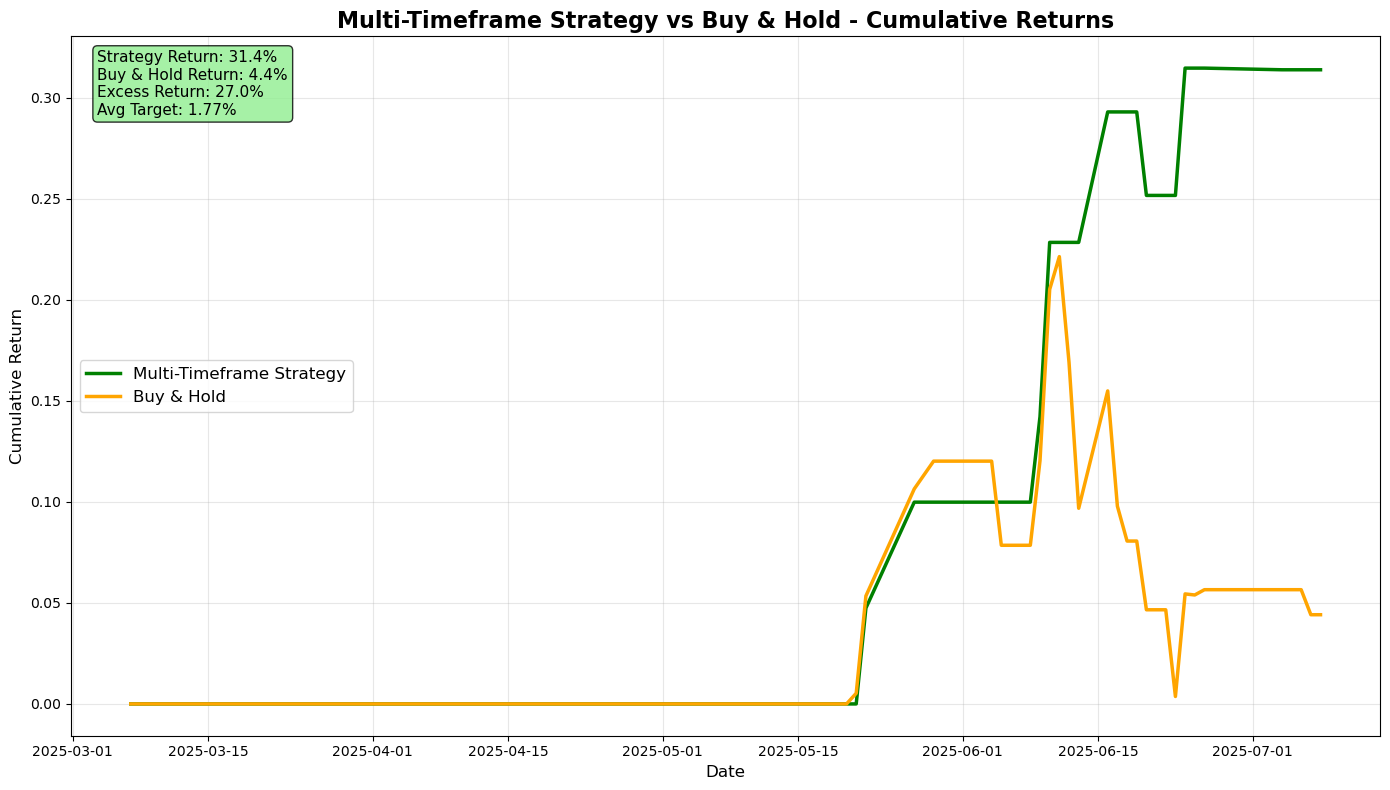

In [51]:
results, performance = run_strategy(merged3)

<Axes: xlabel='Date'>

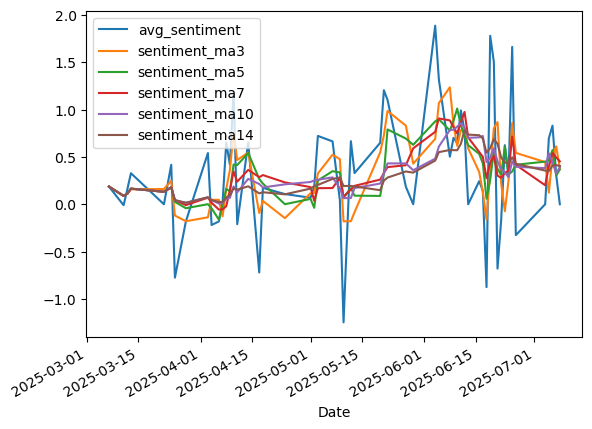

In [69]:
merged3[["avg_sentiment",
         "sentiment_ma3",
         "sentiment_ma5",
        "sentiment_ma7",
        "sentiment_ma10",
        "sentiment_ma14",]].plot()

In [57]:
merged3

,ETHE,% Change,avg_sentiment,num_posts,sentiment_ma7,sentiment_ma3,sentiment_ma5,sentiment_ma10,sentiment_ma14,sentiment_ma21,...,sentiment_ewma90,sentiment_ewma100,sentiment_ewma250,sentiment_ewma_custom,sentiment_momentum3,sentiment_momentum7,sentiment_vol7,sentiment_vol14,sentiment_zscore7,sentiment_zscore14
Date,,,,,,,,,,,,,,,,,,,,,
2025-03-07,18.000000,-0.019608,0.186870,11,0.186870,0.186870,0.186870,0.186870,0.186870,0.186870,...,0.186870,0.186870,0.186870,0.186870,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-11,16.260000,0.044987,-0.009911,22,0.088480,0.088480,0.088480,0.088480,0.088480,0.088480,...,0.087386,0.087496,0.088086,0.063882,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-12,15.670000,-0.036285,0.154384,43,0.110448,0.110448,0.110448,0.110448,0.110448,0.110448,...,0.110217,0.110239,0.110362,0.110057,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-13,15.420000,-0.015954,0.328081,12,0.164856,0.157518,0.164856,0.164856,0.164856,0.164856,...,0.166512,0.166344,0.165447,0.210252,0.141211,NaN,NaN,NaN,NaN,NaN
2025-03-22,16.459999,0.000000,0.000000,1,0.131885,0.160822,0.131885,0.131885,0.131885,0.131885,...,0.131713,0.131732,0.131826,0.119060,-0.088480,NaN,NaN,NaN,NaN,NaN
2025-03-24,17.430000,0.058931,0.416823,7,0.179375,0.248301,0.177875,0.179375,0.179375,0.179375,...,0.181910,0.181654,0.180281,0.243994,0.306375,NaN,NaN,NaN,NaN,NaN
2025-03-25,17.299999,-0.007458,-0.775418,3,0.042976,-0.119532,0.024774,0.042976,0.042976,0.042976,...,0.035865,0.036590,0.040454,-0.175514,-0.932936,NaN,0.393399,NaN,-2.080315,NaN
2025-03-28,15.610000,-0.065829,-0.179442,9,-0.009355,-0.179346,-0.041991,0.015173,0.015173,0.015173,...,0.006812,0.007659,0.012191,-0.177112,-0.340264,-0.366313,0.395426,NaN,-0.430137,NaN
2025-04-03,14.870000,-0.067127,0.540813,3,0.069320,-0.138016,0.000555,0.073578,0.073578,0.073578,...,0.071555,0.071747,0.072824,0.112981,0.292511,0.452333,0.446753,NaN,1.055377,NaN
